# Collect Stored Experiment Results

This notebook loads the metrics already saved in `results.json` under `Results/`,
and summarises concordance index (CI) and integrated Brier score (IBS) across seeds
for the `nasa`, `churn_lastfm_months`, and `mimic` datasets.


In [8]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

PROJECT_ROOT = Path('..').resolve()
RESULTS_ROOT = PROJECT_ROOT / 'Results'
DATASETS = {'nasa', 'churn_lastfm_months', 'mimic', 'big_rw'}


In [9]:

records = []
failures = []

seed_dirs = [
    p
    for p in RESULTS_ROOT.glob('*/**/seed_*')
    if len(p.relative_to(RESULTS_ROOT).parts) >= 7
    and p.relative_to(RESULTS_ROOT).parts[1] in DATASETS
    and p.name.split('_')[-1].isdigit()
    and 0 <= int(p.name.split('_')[-1]) <= 10
]
seed_dirs.sort()

for seed_dir in seed_dirs:
    parts = seed_dir.relative_to(RESULTS_ROOT).parts
    if len(parts) < 7:
        failures.append({'path': str(seed_dir), 'reason': 'Unexpected directory schema'})
        continue

    agent_name, dataset_name, architecture, lambda_dir, landmark_dir, experiment, seed_name = parts[:7]
    results_path = seed_dir / 'results.json'
    if not results_path.exists():
        failures.append({'path': str(seed_dir), 'reason': 'Missing results.json'})
        continue

    lambda_token = lambda_dir.split('_', 1)[1] if '_' in lambda_dir else None
    lambda_value_raw = None
    try:
        lambda_value_raw = float(lambda_token) if lambda_token not in (None, 'None') else None
    except ValueError:
        lambda_value_raw = None

    if lambda_value_raw == 0.0 and agent_name not in {'SA', 'DDH'}:
        continue

    if agent_name in {'SA', 'DDH'}:
        lambda_value = None
    else:
        lambda_value = lambda_value_raw

    landmark_token = landmark_dir.split('_', 1)[1] if '_' in landmark_dir else 'False'
    landmark_value = landmark_token.lower() == 'true'

    try:
        seed_value = int(seed_name.split('_')[-1])
    except ValueError:
        failures.append({'path': str(seed_dir), 'reason': f'Could not parse seed from {seed_name}'})
        continue

    try:
        with open(results_path, 'r') as fh:
            metrics = json.load(fh)
    except Exception as exc:
        failures.append({'path': str(seed_dir), 'reason': f'Failed to load metrics: {exc}'})
        continue

    records.append({
        'agent': agent_name,
        'dataset': dataset_name,
        'architecture': architecture,
        'lambda': lambda_value,
        'landmark': landmark_value,
        'experiment': experiment,
        'seed': seed_value,
        'ci': metrics.get('ci'),
        'ibs': metrics.get('ibs', metrics.get('bs')),
        'path': str(results_path),
    })

results_df = pd.DataFrame(records)
if not results_df.empty:
    rename_map = {'SA': 'Cox', 'DeepLambdaSA': 'TC-Cox'}
    results_df['agent_display'] = results_df['agent'].replace(rename_map)
else:
    results_df['agent_display'] = pd.Series(dtype=str)



In [10]:

print(f"Loaded entries: {len(results_df)}")
print(f"Failures: {len(failures)}")
if failures:
    display(pd.DataFrame(failures))

results_df.head()

if not results_df.empty:
    pivot_cols = ['agent_display', 'dataset', 'landmark', 'lambda']
    agg = (
        results_df.groupby(pivot_cols, dropna=False)[['ci', 'ibs']]
        .agg(['mean', 'std', 'count'])
        .sort_index()
    )
    display(agg)



Loaded entries: 216
Failures: 2


,path,reason
0,/Users/mariana/Documents/col/lts4/survan/Resul...,Missing results.json
1,/Users/mariana/Documents/col/lts4/survan/Resul...,Missing results.json


ci                  \
                                                       mean       std count   
agent_display dataset             landmark lambda                             
Cox           big_rw              False    NaN     0.871682  0.017021    11   
                                  True     NaN     0.941571  0.016317    11   
              churn_lastfm_months False    NaN     0.810838  0.033285    11   
                                  True     NaN     0.825541  0.041253    11   
              mimic               False    NaN     0.500000  0.000000    10   
                                  True     NaN     0.556007  0.108911    10   
              nasa                False    NaN     0.505095  0.015253    11   
                                  True     NaN     0.625054  0.041656    11   
TC-Cox        big_rw              True     0.10    0.925549  0.023561    11   
                                           0.90    0.962439  0.015516    11   
                                           0.95    0.956965  0.011818    11   
              churn_lastfm_months True     0.10    0.862267  0.039085    11   
                                           0.90    0.891154  0.024710    11   
                                           0.95    0.885654  0.028453    11   
              mimic               True     0.10    0.563246  0.298186     9   
                                           0.90    0.607091  0.300240    11   
                                           0.95    0.558955  0.291942    11   
              nasa                True     0.10    0.457362  0.093938    11   
                                           0.90    0.718357  0.107641    11   
                                           0.95    0.732542  0.116498    11   

                                                        ibs                  
                                                       mean       std count  
agent_display dataset             landmark lambda                            
Cox           big_rw              False    NaN     0.072404  0.012681    11  
                                  True     NaN     0.047553  0.009364    11  
              churn_lastfm_months False    NaN     0.135575  0.051507    11  
                                  True     NaN     0.119712  0.035187    11  
              mimic               False    NaN     0.198559  0.053711    10  
                                  True     NaN     0.161824  0.042718    10  
              nasa                False    NaN     0.306044  0.068931    11  
                                  True     NaN     0.135221  0.021062    11  
TC-Cox        big_rw              True     0.10    0.125958  0.017165    11  
                                           0.90    0.029569  0.009686    11  
                                           0.95    0.032063  0.007353    11  
              churn_lastfm_months True     0.10    0.110328  0.014274    11  
                                           0.90    0.084673  0.016609    11  
                                           0.95    0.081551  0.017266    11  
              mimic               True     0.10    0.566669  0.040774     9  
                                           0.90    0.177381  0.086052    11  
                                           0.95    0.132175  0.049399    11  
              nasa                True     0.10    0.472332  0.048276    11  
                                           0.90    0.100669  0.024813    11  
                                           0.95    0.091938  0.033724    11

In [11]:

print(f"Loaded entries: {len(results_df)}")
print(f"Failures: {len(failures)}")
if failures:
    display(pd.DataFrame(failures))

results_df.head()

if not results_df.empty:
    pivot_cols = ['agent', 'dataset', 'landmark', 'lambda']
    agg = (
        results_df.groupby(pivot_cols)[['ci', 'ibs']]
        .agg(['mean', 'std', 'count'])
        .sort_index()
    )
    display(agg)


Loaded entries: 216
Failures: 2


,path,reason
0,/Users/mariana/Documents/col/lts4/survan/Resul...,Missing results.json
1,/Users/mariana/Documents/col/lts4/survan/Resul...,Missing results.json


ci                  \
                                                      mean       std count   
agent        dataset             landmark lambda                             
DeepLambdaSA big_rw              True     0.10    0.925549  0.023561    11   
                                          0.90    0.962439  0.015516    11   
                                          0.95    0.956965  0.011818    11   
             churn_lastfm_months True     0.10    0.862267  0.039085    11   
                                          0.90    0.891154  0.024710    11   
                                          0.95    0.885654  0.028453    11   
             mimic               True     0.10    0.563246  0.298186     9   
                                          0.90    0.607091  0.300240    11   
                                          0.95    0.558955  0.291942    11   
             nasa                True     0.10    0.457362  0.093938    11   
                                          0.90    0.718357  0.107641    11   
                                          0.95    0.732542  0.116498    11   

                                                       ibs                  
                                                      mean       std count  
agent        dataset             landmark lambda                            
DeepLambdaSA big_rw              True     0.10    0.125958  0.017165    11  
                                          0.90    0.029569  0.009686    11  
                                          0.95    0.032063  0.007353    11  
             churn_lastfm_months True     0.10    0.110328  0.014274    11  
                                          0.90    0.084673  0.016609    11  
                                          0.95    0.081551  0.017266    11  
             mimic               True     0.10    0.566669  0.040774     9  
                                          0.90    0.177381  0.086052    11  
                                          0.95    0.132175  0.049399    11  
             nasa                True     0.10    0.472332  0.048276    11  
                                          0.90    0.100669  0.024813    11  
                                          0.95    0.091938  0.033724    11

In [12]:
xticks_dict = {
    'churn_lastfm_months': 'LastFM',
    'mimic': 'MIMIC-IV',
    'nasa': 'NASA',
    'big_rw': 'LargeRW'
}

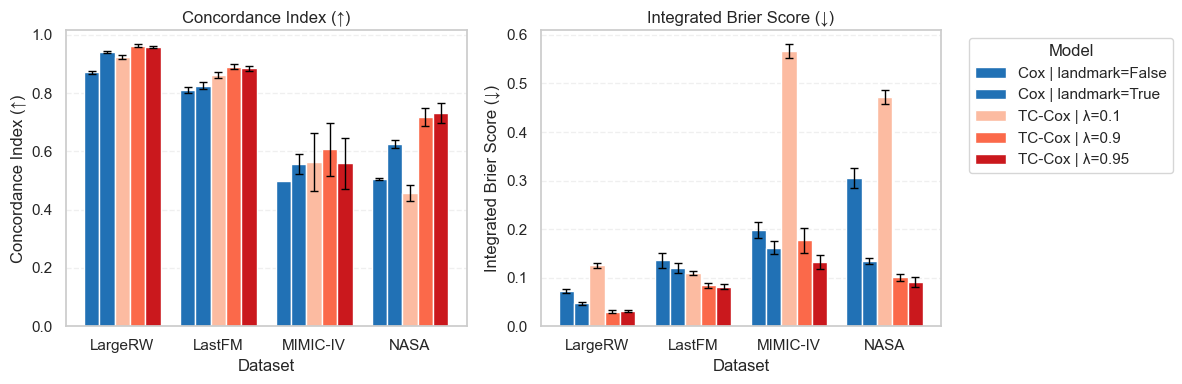

In [13]:

if not results_df.empty:
    plot_df = results_df.copy()
    baseline_agents = {'Cox', 'LambdaSA', 'DDH'}
    tc_agents = {'TC-Cox', 'DDH-TC'}

    group_cols = ['agent_display', 'dataset', 'landmark', 'lambda']
    agg_df = (
        plot_df
        .groupby(group_cols, dropna=False)[['ci', 'ibs']]
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    agg_df.columns = [
        'agent_display', 'dataset', 'landmark', 'lambda',
        'ci_mean', 'ci_std', 'ci_count',
        'ibs_mean', 'ibs_std', 'ibs_count'
    ]
    agg_df['ci_se'] = agg_df['ci_std'] / np.sqrt(agg_df['ci_count'].clip(lower=1))
    agg_df['ibs_se'] = agg_df['ibs_std'] / np.sqrt(agg_df['ibs_count'].clip(lower=1))

    # Build consistent color dictionaries
    baseline_lambda_values = sorted(v for v in agg_df.loc[agg_df['agent_display'].isin(baseline_agents), 'lambda'].dropna().unique())
    tc_lambda_values = sorted(v for v in agg_df.loc[agg_df['agent_display'].isin(tc_agents), 'lambda'].dropna().unique())

    baseline_palette = sns.color_palette('Blues', max(1, len(baseline_lambda_values) + (1 if baseline_lambda_values else 0)))
baseline_no_lambda_colors = {False: '#9ecae1', True: '#08519c'}
baseline_lambda_colors = {lam: col for lam, col in zip(baseline_lambda_values, baseline_palette[1:])}
    tc_lambda_colors = {lam: color for lam, color in zip(tc_lambda_values, sns.color_palette('Reds', max(1, len(tc_lambda_values))))}

    baseline_no_lambda_colors = {False: '#9ecae1', True: '#08519c'}
baseline_landmark_free_default = '#9ecae1'
    tc_no_lambda_colors = {False: '#fcbba1', True: '#cb181d'}

    # expose for other cells
    globals()['BASELINE_LAMBDA_COLORS'] = baseline_lambda_colors
    globals()['TC_LAMBDA_COLORS'] = tc_lambda_colors
    globals()['BASELINE_NO_LAMBDA_COLORS'] = baseline_no_lambda_colors
    globals()['TC_NO_LAMBDA_COLORS'] = tc_no_lambda_colors

    def format_lambda(agent, value):
        if value is None:
            return ''
        if isinstance(value, float) and np.isnan(value):
            return ''
        if agent in {'Cox', 'DDH'}:
            return ''
        return f'λ={value}'

    def build_label(row):
        parts = [row['agent_display']]
        if row['agent_display'] not in {'TC-Cox', 'DDH-TC'}:
            parts.append(f"landmark={row['landmark']}")
        lambda_str = format_lambda(row['agent_display'], row['lambda'])
        if lambda_str:
            parts.append(lambda_str)
        return ' | '.join(parts)

    agg_df['label'] = agg_df.apply(build_label, axis=1)
    agg_df['dataset_display'] = agg_df['dataset'].map(xticks_dict).fillna(agg_df['dataset'])

    def label_agent(label):
        return label.split(' | ')[0]

    ordered_labels = []
    for agent in ['Cox', 'LambdaSA', 'DDH', 'TC-Cox', 'DDH-TC']:
        labels_agent = agg_df.loc[agg_df['agent_display'] == agent, 'label'].unique().tolist()
        ordered_labels.extend(labels_agent)
    ordered_labels = [lbl for lbl in ordered_labels if lbl in agg_df['label'].unique()]

    datasets_sorted = sorted(agg_df['dataset'].unique())
    x = np.arange(len(datasets_sorted))
    groups = max(1, len(ordered_labels))
    total_width = 0.8
    bar_width = total_width / groups
    offsets = -total_width / 2 + bar_width / 2 + np.arange(groups) * bar_width

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
    metrics = [
        ('ci_mean', 'ci_se', 'Concordance Index (↑)', axes[0]),
        ('ibs_mean', 'ibs_se', 'Integrated Brier Score (↓)', axes[1]),
    ]

    for mean_col, se_col, title, ax in metrics:
        for idx_label, label in enumerate(ordered_labels):
            rows = agg_df[agg_df['label'] == label]
            if rows.empty:
                continue
            means = rows.set_index('dataset')[mean_col]
            ses = rows.set_index('dataset')[se_col]
            heights, errors, positions = [], [], []
            for di, dataset in enumerate(datasets_sorted):
                if dataset in means.index:
                    heights.append(means.loc[dataset])
                    errors.append(ses.loc[dataset])
                    positions.append(x[di] + offsets[idx_label])
            if not heights:
                continue
            agent = label_agent(label)
            lam_val = rows['lambda'].iloc[0]
            landmark_val = bool(rows['landmark'].iloc[0])
            if lam_val is None:
                color = baseline_no_lambda_colors[landmark_val] if agent in baseline_agents else tc_no_lambda_colors.get(landmark_val, '#cb181d')
            else:
                if agent in baseline_agents:
                    color = baseline_lambda_colors.get(lam_val, '#2171b5')
                else:
                    color = tc_lambda_colors.get(lam_val, '#fb6a4a')
            bars = ax.bar(positions, heights, bar_width, color=color, label=label)
            for bar, err in zip(bars, errors):
                if pd.isna(err) or err == 0.0:
                    continue
                ax.errorbar(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    yerr=err,
                    fmt='none', ecolor='black', capsize=3, lw=1
                )
        ax.set_xticks(x)
        ax.set_xticklabels([xticks_dict.get(ds, ds) for ds in datasets_sorted], rotation=0)
        ax.set_title(title)
        ax.set_xlabel('Dataset')
        ax.set_ylabel(title)
        ax.grid(True, axis='y', linestyle='--', alpha=0.3)
        ax.grid(False, axis='x')

    handles, labels = axes[0].get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    if unique:
        axes[1].legend(unique.values(), unique.keys(), title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('results_plot_COX.pdf', bbox_inches='tight')
    plt.show()
else:
    print('No results to plot.')




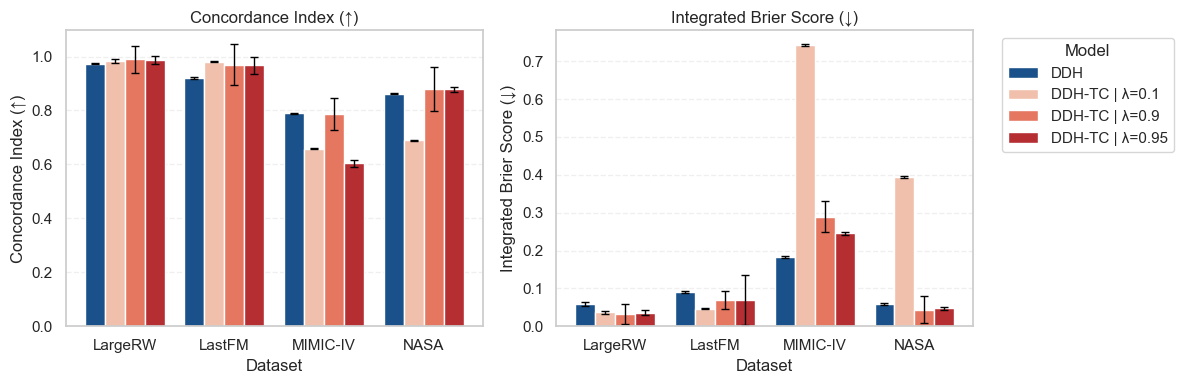

In [14]:

BASELINE_DDH_ROOTS = [
    (PROJECT_ROOT / 'baselines' / 'DDH_results', 'DDH'),
    (PROJECT_ROOT / 'baselines' / 'DDH_results_TC', 'DDH-TC'),
]
BASELINE_DATASETS = {'nasa', 'churn_lastfm_months', 'mimic', 'big_rw'}

ddh_records = []
for root_path, label in BASELINE_DDH_ROOTS:
    if not root_path.exists():
        continue
    for dataset_dir in BASELINE_DATASETS:
        dataset_path = root_path / dataset_dir
        if not dataset_path.exists():
            continue
        for json_path in dataset_path.rglob('results.json'):
            parts = json_path.relative_to(dataset_path).parts
            seed_value = None
            lambda_value = None
            for part in parts:
                if part.startswith('seed_') and part.split('_')[-1].isdigit():
                    seed_value = int(part.split('_')[-1])
                if part.startswith('lambda_'):
                    token = part.split('_', 1)[1]
                    try:
                        lambda_value = float(token)
                    except ValueError:
                        lambda_value = None
            if seed_value is None:
                continue
            if lambda_value == 0.0 and label == 'DDH-TC':
                continue
            try:
                with open(json_path, 'r') as fh:
                    metrics = json.load(fh)
            except Exception:
                continue
            ddh_records.append({
                'dataset': dataset_dir,
                'model': label,
                'lambda': lambda_value,
                'seed': seed_value,
                'ci': metrics.get('ci'),
                'ibs': metrics.get('ibs', metrics.get('bs')),
                'path': str(json_path),
            })

ddh_df = pd.DataFrame(ddh_records)
if not ddh_df.empty:
    ddh_df = ddh_df.sort_values(['dataset', 'model', 'lambda', 'seed']).reset_index(drop=True)
else:
    print('No DDH baseline results found.')

if not ddh_df.empty:
    agg_ddh = (
        ddh_df.groupby(['dataset', 'model', 'lambda'], dropna=False)[['ci', 'ibs']]
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    agg_ddh.columns = ['dataset', 'model', 'lambda', 'ci_mean', 'ci_std', 'ci_count', 'ibs_mean', 'ibs_std', 'ibs_count']
    agg_ddh['ci_se'] = agg_ddh['ci_std'] / np.sqrt(agg_ddh['ci_count'].clip(lower=1))
    agg_ddh['ibs_se'] = agg_ddh['ibs_std'] / np.sqrt(agg_ddh['ibs_count'].clip(lower=1))
    agg_ddh['dataset_display'] = agg_ddh['dataset'].map(xticks_dict).fillna(agg_ddh['dataset'])

    def format_lambda(value):
        if value is None or (isinstance(value, float) and np.isnan(value)):
            return ''
        return f'λ={value}'

    agg_ddh['label'] = (
        agg_ddh['model']
        + agg_ddh['lambda'].apply(lambda v: f" | {format_lambda(v)}" if format_lambda(v) else '')
    )

    ordered_labels = agg_ddh['label'].unique().tolist()

    # Reuse colors from the first plot
    baseline_colors = globals().get('BASELINE_LAMBDA_COLORS', {})
    tc_colors = globals().get('TC_LAMBDA_COLORS', {})
    baseline_no_lambda = globals().get('BASELINE_NO_LAMBDA_COLORS', {False: '#9ecae1', True: '#08519c'})
    tc_no_lambda = globals().get('TC_NO_LAMBDA_COLORS', {False: '#fcbba1', True: '#cb181d'})

    palette = {}
    for lbl in ordered_labels:
        model = 'DDH-TC' if lbl.startswith('DDH-TC') else 'DDH'
        lam_str = lbl.split('|')[-1].strip() if '|' in lbl else ''
        lam_val = None
        if lam_str.startswith('λ='):
            try:
                lam_val = float(lam_str.replace('λ=', ''))
            except ValueError:
                lam_val = None
        if lam_val is None:
            palette[lbl] = baseline_no_lambda[True] if model == 'DDH' else tc_no_lambda[True]
        else:
            if model == 'DDH':
                palette[lbl] = baseline_colors.get(lam_val, '#2171b5')
            else:
                palette[lbl] = tc_colors.get(lam_val, '#fb6a4a')

    agg_ddh = agg_ddh.sort_values(['dataset_display', 'label']).reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
    for ax_idx, (ax, mean_col, se_col, title) in enumerate([
        (axes[0], 'ci_mean', 'ci_se', 'Concordance Index (↑)'),
        (axes[1], 'ibs_mean', 'ibs_se', 'Integrated Brier Score (↓)'),
    ]):
        sns.barplot(
            data=agg_ddh,
            x='dataset_display',
            y=mean_col,
            hue='label',
            palette=palette,
            ax=ax,
            errorbar=None,
        )
        for patch, (_, row) in zip(ax.patches, agg_ddh.iterrows()):
            err = row[se_col]
            if pd.isna(err) or err == 0.0:
                continue
            ax.errorbar(
                patch.get_x() + patch.get_width() / 2,
                patch.get_height(),
                yerr=err,
                fmt='none', ecolor='black', capsize=3, lw=1
            )
        ax.set_title(title)
        ax.set_xlabel('Dataset')
        ax.set_ylabel(title)
        ax.tick_params(axis='x', rotation=0)
        ax.grid(True, axis='y', linestyle='--', alpha=0.3)
        ax.grid(False, axis='x')
        ymin, ymax = ax.get_ylim()
        ax.set_ylim(bottom=0, top=ymax)
    leg0 = axes[0].get_legend()
    if leg0 is not None:
        leg0.remove()
    axes[1].legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('results_plot_DDH.pdf', bbox_inches='tight')
    plt.show()
else:
    print('No DDH baseline results found.')


In [74]:
# ddh_df[ddh_df.dataset == 'mimic']

In [35]:
agg_ddh[agg_ddh.dataset == 'mimic']

,dataset,model,lambda,ci_mean,ci_std,ci_count,ibs_mean,ibs_std,ibs_count,ci_se,ibs_se,dataset_display,label
8,mimic,DDH,NaN,0.789230,0.170235,11,0.183584,0.089021,11,0.051328,0.026841,MIMIC,DDH
9,mimic,TC-DDH,0.10,0.601190,0.213291,5,0.741174,0.072739,5,0.095387,0.032530,MIMIC,TC-DDH | λ=0.1
10,mimic,TC-DDH,0.90,0.818452,0.212376,4,0.298285,0.158007,4,0.106188,0.079003,MIMIC,TC-DDH | λ=0.9
11,mimic,TC-DDH,0.95,0.683333,0.241828,4,0.216480,0.132157,4,0.120914,0.066078,MIMIC,TC-DDH | λ=0.95
